In [2]:
import pandas as pd 
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, matthews_corrcoef
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV, ParameterGrid
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import librosa
import warnings
from sklearn.metrics import f1_score
warnings.filterwarnings("ignore")
import pandas as pd 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import f1_score
warnings.filterwarnings("ignore")
from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
def boostrap(X_train, Y_train):
    train_data = X_train.copy()
    train_data['target'] = Y_train
    minority = train_data[train_data['target'] == 1]
    majority = train_data[train_data['target'] == 0]

    # Crear bootstrap sample de la minoría con reemplazo para igualar tamaño de mayoría
    minority_bootstrap = minority.sample(n=len(majority), replace=True, random_state=42)

    # Combinar
    train_balanced = pd.concat([majority, minority_bootstrap], ignore_index=True).sample(frac=1, random_state=42)

    # Separar X e y
    X_train_balanced = train_balanced.drop('target', axis=1)
    y_train_balanced = train_balanced['target']

    return X_train_balanced, y_train_balanced


def eval(model_name, model, target_names, X_train, X_test, y_test, y_pred, proba=False): 
    print(f"\nEvaluando modelo: {model_name} para {target_names} \n")

    print("Reporte de clasificación (Random Forest):\n")
    print(classification_report(y_test, y_pred, target_names=target_names))
    print("Precisión del modelo:", accuracy_score(y_test, y_pred))
    print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))
    print("F1-score (weighted):", f1_score(y_test, y_pred, average='weighted'))
    print("F1-score (micro):", f1_score(y_test, y_pred, average='micro'))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de confusión - Random Forest")
    plt.show()
    if proba: 
        y_prob = model.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Curva ROC')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    if model_name == 'arbol':
        importancia = pd.DataFrame({
            'feature': X_train.columns,
            'importancia': model.feature_importances_
        }).sort_values(by='importancia', ascending=False)

        print("Top 10 Features más importantes (Random Forest):\n")
        print(importancia.head(10))

        # Plot
        plt.figure(figsize=(10, 6))
        sns.barplot(x='importancia', y='feature', data=importancia.head(10), palette='crest')
        plt.title("Top 10 Features más importantes (Random Forest)")
        plt.xlabel("Importancia")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

def extraer_features_audio(y, sr, n_mfcc=13):
    features = {}

    # MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    for i in range(n_mfcc):
        features[f'MFCC_{i+1}_mean'] = np.mean(mfccs[i])
        features[f'MFCC_{i+1}_std'] = np.std(mfccs[i])

    # Brillo espectral (Spectral Centroid)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features['spectral_centroid_mean'] = np.mean(centroid)
    features['spectral_centroid_std'] = np.std(centroid)

    # Inharmonicidad (Spectral Flatness)
    flatness = librosa.feature.spectral_flatness(y=y)
    features['spectral_flatness_mean'] = np.mean(flatness)

    # Aperiodicidad aproximada (Zero Crossing Rate)
    zcr = librosa.feature.zero_crossing_rate(y)
    features['zcr_mean'] = np.mean(zcr)

    # HNR aproximado con librosa
    harm = librosa.effects.harmonic(y)
    noise = librosa.effects.percussive(y)
    hnr = 10 * np.log10(np.sum(harm ** 2) / (np.sum(noise ** 2) + 1e-6))
    features['hnr_librosa'] = hnr

    return features

    

In [2]:
dic_class = {0: 'healthy', 1: 'not healthy', 2: 'unknown'}
dic_class_cat = {'healthy': 0, 'not healthy': 1, 'unknown': 2}

df = pd.read_csv(r'.\voice-audios\dataset_audio_total.csv')

nombres_significativos =   ['MFCC_2_mean', 'spectral_flatness_mean', 'zcr_mean', 'hnr_librosa', 'spectral_centroid_mean', 'MFCC_1_mean', 'MFCC_13_std', 'MFCC_12_std', 'MFCC_11_std', 'MFCC_2_std', 'MFCC_7_mean', 'MFCC_13_mean', 'MFCC_3_mean', 'MFCC_4_mean', 'MFCC_11_mean', 'MFCC_10_std', 'MFCC_9_std', 'spectral_centroid_std', 'MFCC_1_std', 'MFCC_9_mean', 'MFCC_3_std', 'MFCC_5_mean']

NameError: name 'pd' is not defined

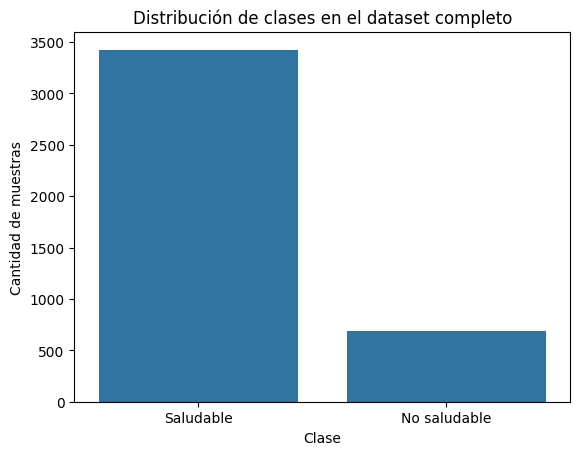

clase
0    3424
1     684
Name: count, dtype: int64


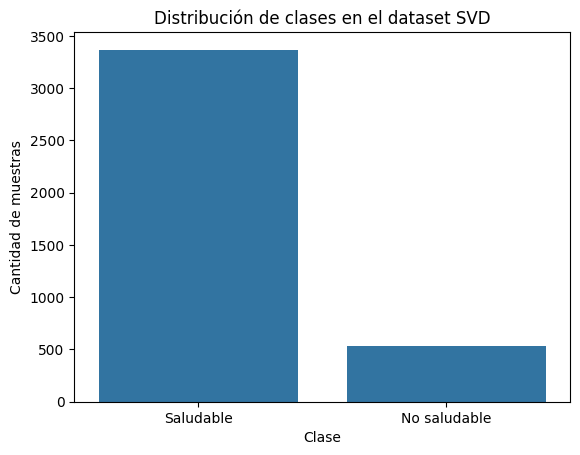

clase
0    3367
1     533
Name: count, dtype: int64


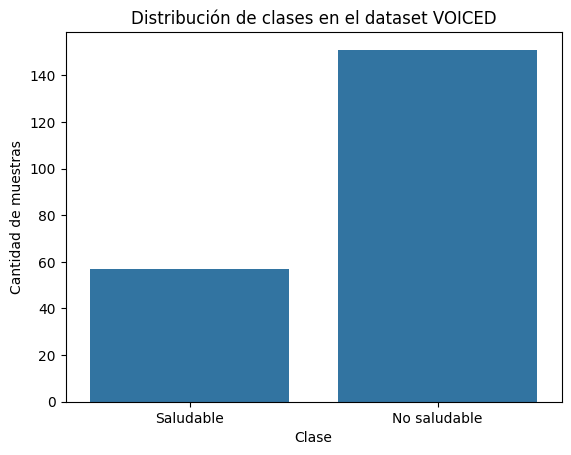

clase
1    151
0     57
Name: count, dtype: int64


In [9]:
cols_to_convert = df.columns.difference(['file_name'])
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

voiced_mask = df['file_name'].str.startswith('voice')

df_SVD = df[~voiced_mask].reset_index(drop=True)
df_VOICED = df[voiced_mask].reset_index(drop=True)

sns.countplot(x='clase', data=df)
plt.title('Distribución de clases en el dataset completo')
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
plt.xticks([0, 1], ['Saludable', 'No saludable'])
plt.show()

print(df['clase'].value_counts())

sns.countplot(x='clase', data=df_SVD)
plt.title('Distribución de clases en el dataset SVD')
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
plt.xticks([0, 1], ['Saludable', 'No saludable'])
plt.show()

print(df_SVD['clase'].value_counts())

sns.countplot(x='clase', data=df_VOICED)
plt.title('Distribución de clases en el dataset VOICED')
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
plt.xticks([0, 1], ['Saludable', 'No saludable'])
plt.show()

print(df_VOICED['clase'].value_counts())


In [35]:
X, y =  df_VOICED.drop(['clase', 'file_name'], axis=1), df_VOICED['clase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def balancear(X, y):
    df = X.copy()
    df['clase'] = y

    df_min = df[df['clase'] == 1]
    df_maj = df[df['clase'] == 0]

    df_min_upsampled = resample(
        df_min,
        replace=True,
        n_samples=len(df_maj),
        random_state=42
    )

    df_balanced = pd.concat([df_maj, df_min_upsampled])
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

    X_bal = df_balanced.drop(columns='clase')
    y_bal = df_balanced['clase']

    return X_bal, y_bal


X_train, y_train = balancear(X_train, y_train)


In [36]:
models_and_parameters = {
    'SVM': {
        'model': SVC(),
        'params': {
            'clf__kernel': ['rbf', 'poly'],
            'clf__degree': [2, 3, 4, 5, 6],  # solo aplica si kernel='poly'
            'clf__gamma': [0.5, 0.1, 0.05, 0.01, 0.005, 0.001, "auto"],
            'clf__C': [0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000, 3000, 5000, 7000, 10000, 12000]
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'clf__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23],
            'clf__p': [1, 2],
            'clf__weights': ["uniform", "distance"]
        }
    },
    'DT': {
        'model': DecisionTreeClassifier(),
        'params': {
            'clf__criterion': ["gini", "entropy", "log_loss"],
            'clf__splitter': ["best", "random"],
            'clf__min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10],
            'clf__max_features': ["sqrt", "log2"]
        }
    },
    'RF': {
        'model': RandomForestClassifier(),
        'params': {
            'clf__criterion': ["gini"],
            'clf__min_samples_split': [2, 3, 4, 5, 6],
            'clf__n_estimators': [50, 75, 100, 125, 150, 175],
            'clf__max_features': ["sqrt"]
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(),
        'params': {
            'clf__learning_rate': [0.1, 1, 10],
            'clf__n_estimators': [50, 100, 150, 200, 250, 300, 350, 400]
        }
    },
    'NB': {
        'model': GaussianNB(),
        'params': {
            'clf__var_smoothing': [1e-8, 1e-9]
        }
    }
}

best_models = {}

for name, mp in models_and_parameters.items():
    print(f"\n🔍 Running RandomizedSearch for {name}...")

    param_grid = mp['params']
    total_combinations = len(list(ParameterGrid(param_grid)))

    n_iter = min(10, max(5, int(0.2 * total_combinations)))
    
    print(f"🔢 {n_iter} combinaciones aleatorias de {total_combinations} posibles")

    pipe = Pipeline([
        ('scaler', StandardScaler()),  # opcional según el modelo
        ('clf', mp['model'])
    ])

    random_search = RandomizedSearchCV(
        pipe,
        param_distributions=param_grid,
        n_iter=n_iter,
        cv=3,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(X_train, y_train)

    print(f"✅ Best params for {name}: {random_search.best_params_}")
    print(f"✅ Best CV F1 macro: {random_search.best_score_:.4f}")

    best_models[name] = random_search.best_estimator_

from sklearn.metrics import f1_score

print("\n📊 Test F1 Macro Score:")
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f"{name}: {f1:.4f}")



🔍 Running RandomizedSearch for SVM...
🔢 10 combinaciones aleatorias de 980 posibles
✅ Best params for SVM: {'clf__kernel': 'rbf', 'clf__gamma': 0.05, 'clf__degree': 3, 'clf__C': 7000}
✅ Best CV F1 macro: 0.7385

🔍 Running RandomizedSearch for KNN...
🔢 9 combinaciones aleatorias de 48 posibles
✅ Best params for KNN: {'clf__weights': 'distance', 'clf__p': 1, 'clf__n_neighbors': 19}
✅ Best CV F1 macro: 0.7530

🔍 Running RandomizedSearch for DT...
🔢 10 combinaciones aleatorias de 108 posibles
✅ Best params for DT: {'clf__splitter': 'best', 'clf__min_samples_split': 6, 'clf__max_features': 'log2', 'clf__criterion': 'entropy'}
✅ Best CV F1 macro: 0.6431

🔍 Running RandomizedSearch for RF...
🔢 6 combinaciones aleatorias de 30 posibles
✅ Best params for RF: {'clf__n_estimators': 100, 'clf__min_samples_split': 3, 'clf__max_features': 'sqrt', 'clf__criterion': 'gini'}
✅ Best CV F1 macro: 0.7201

🔍 Running RandomizedSearch for AdaBoost...
🔢 5 combinaciones aleatorias de 24 posibles
✅ Best params

In [34]:
def print_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Sensibilidad y especificidad
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # Geometric Mean (GM)
    GM = np.sqrt(sensitivity * specificity)
    
    # Unweighted Average Recall (UAR)
    UAR = (sensitivity + specificity) / 2
    
    # Balanced Measure (BM)
    BM = sensitivity + specificity - 1
    
    # Matthews Correlation Coefficient (MCC)
    MCC = matthews_corrcoef(y_true, y_pred)

    f1macro = f1_score(y_true, y_pred, average='macro')
    
    print(f"Sensitivity (TPR): {sensitivity:.4f}")
    print(f"Specificity (TNR): {specificity:.4f}")
    print(f"F1 macro: {f1macro:.4f}")
    print(f"GM:               {GM:.4f}")
    print(f"UAR:              {UAR:.4f}")
    print(f"BM:               {BM:.4f}")
    print(f"MCC:              {MCC:.4f}")
    

for name, model in best_models.items():
    print(f"\n📌 Métricas para {name}")
    y_pred = model.predict(X_test)
    print_metrics(y_test, y_pred)



📌 Métricas para SVM
Sensitivity (TPR): 0.5701
Specificity (TNR): 0.9554
F1 macro: 0.7802
GM:               0.7380
UAR:              0.7628
BM:               0.5255
MCC:              0.5632

📌 Métricas para KNN
Sensitivity (TPR): 0.7196
Specificity (TNR): 0.9064
F1 macro: 0.7763
GM:               0.8076
UAR:              0.8130
BM:               0.6260
MCC:              0.5612

📌 Métricas para DT
Sensitivity (TPR): 0.4112
Specificity (TNR): 0.9272
F1 macro: 0.6788
GM:               0.6175
UAR:              0.6692
BM:               0.3384
MCC:              0.3593

📌 Métricas para RF
Sensitivity (TPR): 0.5140
Specificity (TNR): 0.9718
F1 macro: 0.7781
GM:               0.7068
UAR:              0.7429
BM:               0.4858
MCC:              0.5703

📌 Métricas para AdaBoost
Sensitivity (TPR): 0.7477
Specificity (TNR): 0.8306
F1 macro: 0.7098
GM:               0.7880
UAR:              0.7891
BM:               0.5783
MCC:              0.4602

📌 Métricas para NB
Sensitivity (TPR): 0.6168
S

In [40]:
X_SVD, y_SVD =  df_SVD.drop(['clase', 'file_name'], axis=1), df_SVD['clase']
X_SVD, y_SVD = balancear(X_SVD, y_SVD)
X_VOICED, y_VOICED =  df_VOICED.drop(['clase', 'file_name'], axis=1), df_VOICED['clase']
X_VOICED, y_VOICED = balancear(X_VOICED, y_VOICED)

In [41]:
best_models_SVD = {
    "SVM": SVC(C=7000, kernel='rbf', gamma=0.05, degree=3, probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=3, weights='uniform', p=1),
    "DT": DecisionTreeClassifier(splitter='best', min_samples_split=4, max_features='sqrt', criterion='gini', random_state=42),
    "RF": RandomForestClassifier(n_estimators=125, min_samples_split=3, max_features='sqrt', criterion='gini', random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=1, random_state=42),
    "NB": GaussianNB(var_smoothing=1e-8)
}

best_models_VOICED = {
    "SVM": SVC(C=7000, kernel='rbf', gamma=0.05, degree=3, probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=19, weights='distance', p=1),
    "DT": DecisionTreeClassifier(splitter='best', min_samples_split=6, max_features='log2', criterion='entropy', random_state=42),
    "RF": RandomForestClassifier(n_estimators=100, min_samples_split=3, max_features='sqrt', criterion='gini', random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, learning_rate=1, random_state=42),
    "NB": GaussianNB(var_smoothing=1e-8)
}

# ----------- Entrenar con VOICED, testear en SVD ------------

print("\n\n🔁 Train: VOICED → Test: SVD")
for name, model in best_models_VOICED.items():
    print(f"\n🔍 Modelo: {name}")
    model.fit(X_VOICED, y_VOICED)
    y_pred = model.predict(X_SVD)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_SVD, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_SVD, y_pred, digits=4))

    print_metrics(y_SVD, y_pred)

# ----------- Entrenar con SVD, testear en VOICED ------------

print("\n\n🔁 Train: SVD → Test: VOICED")
for name, model in best_models_SVD.items():
    print(f"\n🔍 Modelo: {name}")
    model.fit(X_SVD, y_SVD)
    y_pred = model.predict(X_VOICED)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_VOICED, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_VOICED, y_pred, digits=4))

    print_metrics(y_VOICED, y_pred)



🔁 Train: VOICED → Test: SVD

🔍 Modelo: SVM
Confusion Matrix:
[[3367    0]
 [3367    0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5000    1.0000    0.6667      3367
           1     0.0000    0.0000    0.0000      3367

    accuracy                         0.5000      6734
   macro avg     0.2500    0.5000    0.3333      6734
weighted avg     0.2500    0.5000    0.3333      6734

Sensitivity (TPR): 0.0000
Specificity (TNR): 1.0000
F1 macro: 0.3333
GM:               0.0000
UAR:              0.5000
BM:               0.0000
MCC:              0.0000

🔍 Modelo: KNN
Confusion Matrix:
[[1269 2098]
 [ 368 2999]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7752    0.3769    0.5072      3367
           1     0.5884    0.8907    0.7086      3367

    accuracy                         0.6338      6734
   macro avg     0.6818    0.6338    0.6079      6734
weighted avg     0.6818    0.6338 